# 1 - Initial Data Exploration

## Objectives
- Load and inspect the raw dataset
- Understand data structure, types, and basic statistics
- Identify data quality issues (missing values, duplicates, outliers)
- Document initial observations for preprocessing decisions

**Dataset**: Predict Students' Dropout and Academic Success  
**Target**: Student final status (Dropout, Graduate, Enrolled)

## 1.1 Setup and Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from scipy import stats

In [26]:
from src.data.preprocess import load_raw_data, substitute_data, enforce_data_type, get_basic_info

In [27]:
# Add src to path for custom modules
sys.path.append('..')

In [28]:
# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## 1.2 Load raw data

### 1.2.1 Load data

In [29]:
df = load_raw_data('student_dropout_academic_success.csv')

Loading data from: /Users/adrienkt/DataspellProjects/student-dropout-classifier/notebooks/../data/raw/student_dropout_academic_success.csv
Dataset loaded: 4424 rows, 37 columns


Substitute symbolic values with real values

In [30]:
# df = substitute_data(df)
df = enforce_data_type(df)

Enforcing data types...
  Gender → int (binary)
  Scholarship holder → int (binary)
  Debtor → int (binary)
  Tuition fees up to date → int (binary)
  Displaced → int (binary)
  Educational special needs → int (binary)
  International → int (binary)
  Daytime/evening attendance → int (binary)
  Mother's qualification → int (ordinal)
  Father's qualification → int (ordinal)
  Course → category (nominal)
  Application mode → category (nominal)
  Application order → category (nominal)
  Mother's occupation → category (nominal)
  Father's occupation → category (nominal)
  Previous qualification → category (nominal)
  Marital status → category (nominal)
  Nacionality → category (nominal)
  Age at enrollment → float (continuous)
  Previous qualification (grade) → float (continuous)
  Admission grade → float (continuous)
  Curricular units 1st sem (credited) → float (continuous)
  Curricular units 1st sem (enrolled) → float (continuous)
  Curricular units 1st sem (evaluations) → float (contin

### 1.2.2 Display first few rows

First 5 rows:

In [31]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.00,1,19,12,5,9,127.30,1,0,0,1,1,0,20.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,10.80,1.40,1.74,Dropout
1,1,15,1,9254,1,1,160.00,1,1,3,3,3,142.50,1,0,0,0,1,0,19.00,0,0.00,6.00,6.00,6.00,14.00,0.00,0.00,6.00,6.00,6.00,13.67,0.00,13.90,-0.30,0.79,Graduate
2,1,1,5,9070,1,1,122.00,1,37,37,9,9,124.80,1,0,0,0,1,0,19.00,0,0.00,6.00,0.00,0.00,0.00,0.00,0.00,6.00,0.00,0.00,0.00,0.00,10.80,1.40,1.74,Dropout
3,1,17,2,9773,1,1,122.00,1,38,37,5,3,119.60,1,0,0,1,0,0,20.00,0,0.00,6.00,8.00,6.00,13.43,0.00,0.00,6.00,10.00,5.00,12.40,0.00,9.40,-0.80,-3.12,Graduate
4,2,39,1,8014,0,1,100.00,1,37,38,9,9,141.50,0,0,0,1,0,0,45.00,0,0.00,6.00,9.00,5.00,12.33,0.00,0.00,6.00,6.00,6.00,13.00,0.00,13.90,-0.30,0.79,Graduate


Last 5 rows:

In [32]:
df.tail()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
4419,1,1,6,9773,1,1,125.00,1,1,1,5,4,122.20,0,0,0,1,1,0,19.00,0,0.00,6.00,7.00,5.00,13.60,0.00,0.00,6.00,8.00,5.00,12.67,0.00,15.50,2.80,-4.06,Graduate
4420,1,1,2,9773,1,1,120.00,105,1,1,9,9,119.00,1,0,1,0,0,0,18.00,1,0.00,6.00,6.00,6.00,12.00,0.00,0.00,6.00,6.00,2.00,11.00,0.00,11.10,0.60,2.02,Dropout
4421,1,1,1,9500,1,1,154.00,1,37,37,9,9,149.50,1,0,0,1,0,1,30.00,0,0.00,7.00,8.00,7.00,14.91,0.00,0.00,8.00,9.00,1.00,13.50,0.00,13.90,-0.30,0.79,Dropout
4422,1,1,1,9147,1,1,180.00,1,37,37,7,4,153.80,1,0,0,1,0,1,20.00,0,0.00,5.00,5.00,5.00,13.80,0.00,0.00,5.00,6.00,5.00,12.00,0.00,9.40,-0.80,-3.12,Graduate
4423,1,10,1,9773,1,1,152.00,22,38,37,5,9,152.00,1,0,0,1,0,0,22.00,1,0.00,6.00,8.00,6.00,11.67,0.00,0.00,6.00,6.00,6.00,13.00,0.00,12.70,3.70,-1.70,Graduate


## 1.3 Basic Information

In [33]:
get_basic_info(df)


DATASET BASIC INFORMATION

Shape: (4424, 37)

Data Types:
float64    18
int64      10
object      9
Name: count, dtype: int64

Missing Values:
No missing values found!

Duplicate Rows: 0

Target Distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target Proportions:
Target
Graduate    49.9%
Dropout     32.1%
Enrolled    17.9%
Name: proportion, dtype: str


## 1.4 Data Types Inspection

Column Data Types:

In [34]:
# Create a DataFrame with column info
col_info = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null': df.count().values,
    'Null %': (df.isnull().sum() / len(df) * 100).values,
    'Unique': [df[col].nunique() for col in df.columns],
    'Sample Values': [str(df[col].dropna().unique()[:3].tolist()) for col in df.columns]
})

col_info

,Column,Dtype,Non-Null,Null %,Unique,Sample Values
0,Marital status,object,4424,0.00,6,"['1', '2', '4']"
1,Application mode,object,4424,0.00,18,"['17', '15', '1']"
2,Application order,object,4424,0.00,8,"['5', '1', '2']"
3,Course,object,4424,0.00,17,"['171', '9254', '9070']"
4,Daytime/evening attendance,int64,4424,0.00,2,"[1, 0]"
5,Previous qualification,object,4424,0.00,17,"['1', '19', '42']"
6,Previous qualification (grade),float64,4424,0.00,101,"[122.0, 160.0, 100.0]"
7,Nacionality,object,4424,0.00,21,"['1', '62', '6']"
8,Mother's qualification,int64,4424,0.00,29,"[19, 1, 37]"
9,Father's qualification,int64,4424,0.00,34,"[12, 3, 37]"


In [35]:
df.dtypes.value_counts()

float64    18
int64      10
object      9
Name: count, dtype: int64

## 1.5 Target Variable Analysis

### 1.5.1 Count distribution

In [36]:
target_counts = df['Target'].value_counts()
target_pct = df['Target'].value_counts(normalize=True) * 100

# Create summary table
target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_pct.values
})
target_summary['Percentage'] = target_summary['Percentage'].apply(lambda x: f"{x:.1f}%")
target_summary

,Count,Percentage
Target,,
Graduate,2209,49.9%
Dropout,1421,32.1%
Enrolled,794,17.9%


### 1.5.2 Visualization

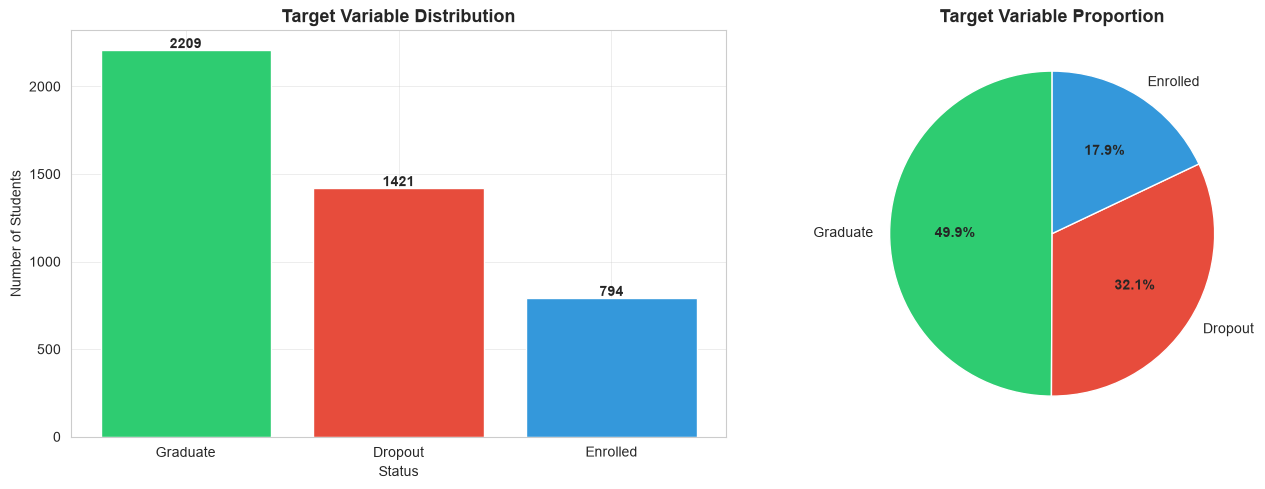

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Dropout': '#e74c3c', 'Graduate': '#2ecc71', 'Enrolled': '#3498db'}

# Bar plot
ax1 = axes[0]
bars = ax1.bar(target_counts.index, target_counts.values,
               color=[colors.get(x, '#95a5a6') for x in target_counts.index])
ax1.set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Status')
ax1.set_ylabel('Number of Students')
for bar, count in zip(bars, target_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', fontweight='bold')

# Pie chart

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(target_counts.values,
                                      labels=target_counts.index,
                                      autopct='%1.1f%%',
                                      colors=[colors.get(x, '#95a5a6') for x in target_counts.index],
                                      startangle=90)
ax2.set_title('Target Variable Proportion', fontsize=13, fontweight='bold')
for autotext in autotexts:
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.6 Missing values analysis

In [38]:
# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f"Found {len(missing_df)} columns with missing values:")
missing_df

Found 0 columns with missing values:


,Column,Missing Count,Missing %


In [39]:
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(missing_df['Column'], missing_df['Missing %'], color='#e74c3c', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values by Column', fontweight='bold')
    ax.invert_yaxis()  # Highest missing at top
    plt.tight_layout()
    plt.show()
else:
    print("- No missing values found in the dataset!")

- No missing values found in the dataset!


## 1.7 Duplicate rows check

In [40]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

print(f"\nDuplicate rows ({duplicates}):")
df[df.duplicated(keep=False)].head(10)

Number of duplicate rows: 0

Duplicate rows (0):


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target


## 1.8 Numerical features statistics

In [41]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Number of numerical features: {len(numerical_cols)}")
print(f"\nNumerical columns: {numerical_cols}")

# Display statistics
df[numerical_cols].describe().T

Number of numerical features: 28

Numerical columns: ['Daytime/evening attendance', 'Previous qualification (grade)', "Mother's qualification", "Father's qualification", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


,count,mean,std,min,25%,50%,75%,max
Daytime/evening attendance,4424.00,0.89,0.31,0.00,1.00,1.00,1.00,1.00
Previous qualification (grade),4424.00,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Mother's qualification,4424.00,19.56,15.60,1.00,2.00,19.00,37.00,44.00
Father's qualification,4424.00,22.28,15.34,1.00,3.00,19.00,37.00,44.00
Admission grade,4424.00,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Displaced,4424.00,0.55,0.50,0.00,0.00,1.00,1.00,1.00
Educational special needs,4424.00,0.01,0.11,0.00,0.00,0.00,0.00,1.00
Debtor,4424.00,0.11,0.32,0.00,0.00,0.00,0.00,1.00
Tuition fees up to date,4424.00,0.88,0.32,0.00,1.00,1.00,1.00,1.00
Gender,4424.00,0.35,0.48,0.00,0.00,0.00,1.00,1.00


## 1.9 Categorical features analysis

In [42]:
# Select categorical/object columns (including target)
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print(f"Number of categorical features: {len(categorical_cols)}")

for col in categorical_cols:
    if col != 'Target':  # Target already analyzed
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        value_counts = df[col].value_counts()
        # Display top 10 categories
        for val, count in value_counts.head(10).items():
            pct = (count / len(df)) * 100
            print(f"    {val}: {count} ({pct:.1f}%)")
        if len(value_counts) > 10:
            print(f"    ... and {len(value_counts) - 10} more categories")

Number of categorical features: 9

Marital status:
  Unique values: 6
    1: 3919 (88.6%)
    2: 379 (8.6%)
    4: 91 (2.1%)
    5: 25 (0.6%)
    6: 6 (0.1%)
    3: 4 (0.1%)

Application mode:
  Unique values: 18
    1: 1708 (38.6%)
    17: 872 (19.7%)
    39: 785 (17.7%)
    43: 312 (7.1%)
    44: 213 (4.8%)
    7: 139 (3.1%)
    18: 124 (2.8%)
    42: 77 (1.7%)
    51: 59 (1.3%)
    16: 38 (0.9%)
    ... and 8 more categories

Application order:
  Unique values: 8
    1: 3026 (68.4%)
    2: 547 (12.4%)
    3: 309 (7.0%)
    4: 249 (5.6%)
    5: 154 (3.5%)
    6: 137 (3.1%)
    9: 1 (0.0%)
    0: 1 (0.0%)

Course:
  Unique values: 17
    9500: 766 (17.3%)
    9147: 380 (8.6%)
    9238: 355 (8.0%)
    9085: 337 (7.6%)
    9773: 331 (7.5%)
    9991: 268 (6.1%)
    9670: 268 (6.1%)
    9254: 252 (5.7%)
    9070: 226 (5.1%)
    171: 215 (4.9%)
    ... and 7 more categories

Previous qualification:
  Unique values: 17
    1: 3717 (84.0%)
    39: 219 (5.0%)
    19: 162 (3.7%)
    3: 126 (2.

## 1.10 Outlier detection (z-score method)

### 1.10.1 Count outliers (z-score > 3)

In [43]:
# Calculate z-scores for numerical columns
z_scores = np.abs(stats.zscore(df[numerical_cols].select_dtypes(include=['float64'])))

# Count outliers (z-score > 3)
outlier_counts = (z_scores > 3).sum()
outlier_pct = (outlier_counts / len(df)) * 100

outlier_summary = pd.DataFrame({
    'Column': numerical_cols[:outlier_counts],
    'Outlier Count': outlier_counts,
    'Outlier %': outlier_pct
})
outlier_summary = outlier_summary[outlier_summary['Outlier Count'] > 0].sort_values('Outlier %', ascending=False)

print(f"Columns with potential outliers (z-score > 3):")
outlier_summary

Columns with potential outliers (z-score > 3):


,Column,Outlier Count,Outlier %
0,Daytime/evening attendance,934,21.11
1,Previous qualification (grade),934,21.11
26,Inflation rate,934,21.11
25,Unemployment rate,934,21.11
24,Curricular units 2nd sem (without evaluations),934,21.11
23,Curricular units 2nd sem (grade),934,21.11
22,Curricular units 2nd sem (approved),934,21.11
21,Curricular units 2nd sem (evaluations),934,21.11
20,Curricular units 2nd sem (enrolled),934,21.11
19,Curricular units 2nd sem (credited),934,21.11


### 1.10.2 Box plots for top outliers

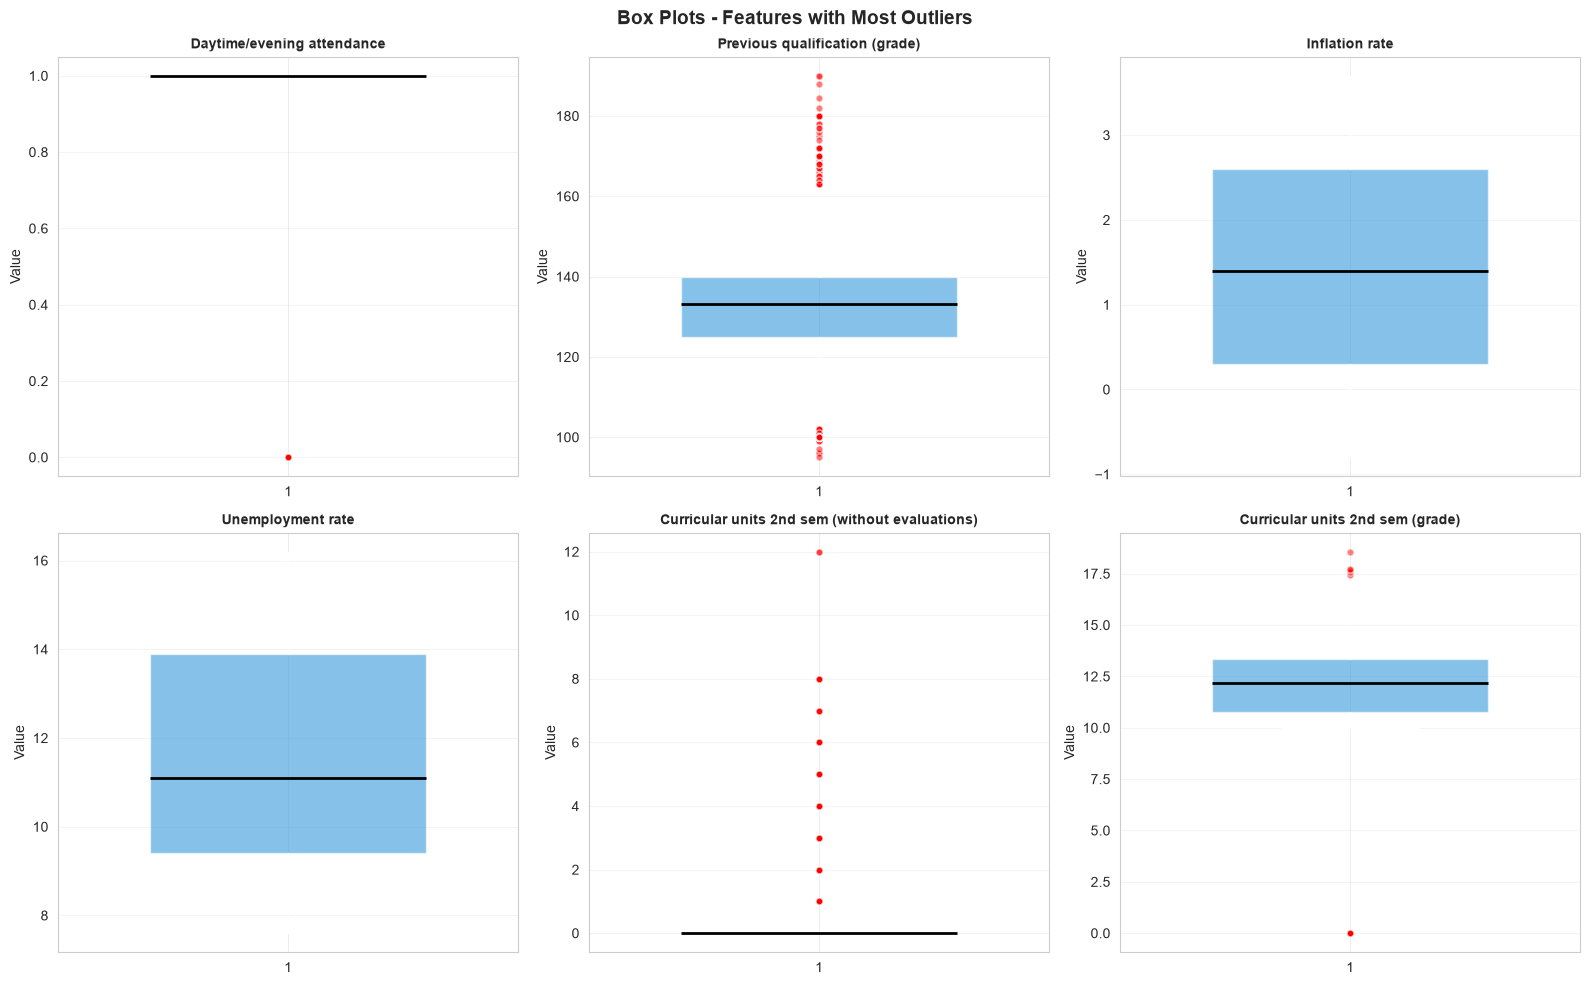

In [44]:
if len(outlier_summary) > 0:
    top_outlier_cols = outlier_summary.head(6)['Column'].tolist()

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, col in enumerate(top_outlier_cols):
        if i >= len(axes):
            break

        # Safely convert column name to string
        col_name = str(col)

        # Check if column exists and is numeric
        if col_name in df.columns and pd.api.types.is_numeric_dtype(df[col_name]):
            # Extract clean numeric values
            values = df[col_name].dropna().values

            if len(values) == 0:
                axes[i].text(0.5, 0.5, 'No data',
                            ha='center', va='center', transform=axes[i].transAxes)
                axes[i].set_title(col_name, fontsize=10, fontweight='bold')
                continue

            # Modern boxplot with orientation parameter
            bp = axes[i].boxplot(
                values,
                orientation='vertical',  # Use 'horizontal' for horizontal boxes
                patch_artist=True,
                widths=0.6,
                medianprops={'color': 'black', 'linewidth': 2},
                flierprops={'marker': 'o', 'markerfacecolor': 'red',
                           'markersize': 5, 'alpha': 0.5}
            )

            # Style the box
            for box in bp['boxes']:
                box.set_facecolor('#3498db')
                box.set_alpha(0.6)

            axes[i].set_title(col_name, fontsize=10, fontweight='bold')
            axes[i].set_ylabel('Value')
            axes[i].grid(axis='y', alpha=0.3)
        else:
            # Column not found or not numeric
            axes[i].text(0.5, 0.5, f'Column not available:\n{col_name}',
                        ha='center', va='center', transform=axes[i].transAxes,
                        fontsize=9, color='gray')
            axes[i].set_title(col_name, fontsize=10, fontweight='bold')

    # Hide any unused subplots
    for i in range(len(top_outlier_cols), len(axes)):
        axes[i].set_visible(False)

    plt.suptitle('Box Plots - Features with Most Outliers', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 1.11 Initial observations

In [45]:
observations = []

# Check class balance
target_dist = df['Target'].value_counts(normalize=True)
if target_dist.max() > 0.6:
    observations.append("-  Class imbalance detected - consider stratified sampling")
else:
    observations.append("- Classes are relatively balanced")

# Check missing values
if missing.sum() > 0:
    observations.append(f"-  {missing.sum()} missing values found - need imputation strategy")
else:
    observations.append("- No missing values")

# Check duplicates
if duplicates > 0:
    observations.append(f"-  {duplicates} duplicate rows found - should be removed")
else:
    observations.append("- No duplicate rows")

# Check feature types
numerical_count = len(numerical_cols)
categorical_count = len(categorical_cols) - 1  # Excluding target
observations.append(f"-  {numerical_count} numerical features, {categorical_count} categorical features")

# Check for potential data leakage
if 'Curricular units 2nd sem' in str(df.columns.tolist()):
    observations.append("-  2nd semester features present - consider for early prediction models")

# Check for 'Enrolled' students
enrolled_count = (df['Target'] == 'Enrolled').sum()
if enrolled_count > 0:
    observations.append(f"-  {enrolled_count} 'Enrolled' students found - may need to filter for binary classification")

for i, obs in enumerate(observations, 1):
    print(f"{i}. {obs}")


1. - Classes are relatively balanced
2. - No missing values
3. - No duplicate rows
4. -  28 numerical features, 8 categorical features
5. -  2nd semester features present - consider for early prediction models
6. -  794 'Enrolled' students found - may need to filter for binary classification


## 1.12 Save processed data

### 1.12.1 Save a copy for the next notebook

In [49]:
df.to_csv('../data/processed/df_initial.csv', index=False)
print("- Data saved to ../data/processed/df_initial.csv")

- Data saved to ../data/processed/df_initial.csv


### 1.12.2 Save a pickle for faster loading

In [50]:
df.to_pickle('../data/processed/df_initial.pkl')
print("- Data saved to ../data/processed/df_initial.pkl")

- Data saved to ../data/processed/df_initial.pkl


## APPENDIX: QUICK DATA DICTIONARY

In [48]:
data_dict = {
    'Target': 'Student final status (Dropout, Graduate, Enrolled)',
    'Gender': '0=Female, 1=Male',
    'Age at enrollment': 'Student age at enrollment time',
    'Scholarship holder': '0=No, 1=Yes',
    'Debtor': '0=No, 1=Yes (outstanding tuition fees)',
    'Tuition fees up to date': '0=No, 1=Yes',
    'Displaced': '0=No, 1=Yes (displaced from home region)',
    'Educational special needs': '0=No, 1=Yes',
    'International': '0=No, 1=Yes',
    'Daytime/evening attendance': '0=Evening, 1=Daytime',
    'Course': 'Course/degree program code',
    'Application mode': 'Method of application',
    'Application order': 'Preference order (0=1st choice)',
    'Admission grade': 'Combined admission score (0-200)',
    'Previous qualification (grade)': 'Final grade from prior education',
    'Curricular units 1st sem (approved)': 'Courses passed in 1st semester',
    'Curricular units 1st sem (grade)': 'Average grade 1st semester (0-20)',
    'Unemployment rate': 'National unemployment rate at enrollment',
    'Inflation rate': 'National inflation rate at enrollment',
    'GDP': 'GDP growth rate at enrollment'
}

print("Key Features Reference:")
print("-" * 50)
for k, v in data_dict.items():
    print(f"  {k}: {v}")

Key Features Reference:
--------------------------------------------------
  Target: Student final status (Dropout, Graduate, Enrolled)
  Gender: 0=Female, 1=Male
  Age at enrollment: Student age at enrollment time
  Scholarship holder: 0=No, 1=Yes
  Debtor: 0=No, 1=Yes (outstanding tuition fees)
  Tuition fees up to date: 0=No, 1=Yes
  Displaced: 0=No, 1=Yes (displaced from home region)
  Educational special needs: 0=No, 1=Yes
  International: 0=No, 1=Yes
  Daytime/evening attendance: 0=Evening, 1=Daytime
  Course: Course/degree program code
  Application mode: Method of application
  Application order: Preference order (0=1st choice)
  Admission grade: Combined admission score (0-200)
  Previous qualification (grade): Final grade from prior education
  Curricular units 1st sem (approved): Courses passed in 1st semester
  Curricular units 1st sem (grade): Average grade 1st semester (0-20)
  Unemployment rate: National unemployment rate at enrollment
  Inflation rate: National inflatio